# Two-Tower AMP MIC Predictor — Quantile-regression CI head
**Self-contained Google Colab notebook** with EDA, per-step reasoning, training, and interpretation.

### The problem
Each row is `(peptide sequence, target organism, activity)` where `activity` is a
MIC-like potency readout. We predict **log₁₀ MIC** for a `(peptide, organism)` pair.
This variant predicts the 5/50/95 quantiles with pinball loss; the 5th & 95th **are** the 90% interval — distribution-free, so it makes no assumption about the shape of the MIC noise and the interval width adapts per peptide.

### Architecture at a glance
- **Peptide tower**: uppercased sequence → HuggingFace **ESM-2** per-residue embeddings → a learnable **Transformer** encoder → attention pooling.
- **Organism tower**: an **FT-Transformer** over the species id (category) *plus* numeric features about that species — a real transformer, not an MLP.
- **Fusion → quantile head** for the point estimate and 90% confidence interval.

### How to run
`Runtime → Change runtime type → GPU` (a free **T4** is enough for the default
150M-parameter frozen ESM-2), then `Runtime → Run all`. Upload `dataset.parquet`
when prompted.

## 1 · Install dependencies
**Why:** Colab ships PyTorch and a GPU driver, but we pin `transformers` (for ESM-2),
`pyarrow` (parquet), and the usual scientific stack so the notebook is reproducible
regardless of the Colab image of the day.

In [1]:
#@title Install
!pip -q install "transformers>=4.40" pyarrow scikit-learn scipy seaborn 2>/dev/null
import torch, transformers
print("torch", torch.__version__, "| CUDA:", torch.cuda.is_available(),
      "| GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only",
      "| transformers", transformers.__version__)

torch 2.11.0+cu128 | CUDA: True | GPU: Tesla T4 | transformers 5.13.1


## 2 · Recreate the validated package
**Why write files instead of pasting code inline:** these `%%writefile` cells recreate
the *exact* modules that were CPU-smoke-tested, so what runs on Colab is byte-identical
to the validated source — no risk of drift from re-typing. `amp_common.py` holds the
chirality-aware featurizer, the **genus-species labeler**, and the honest similarity-
clustered split; `amp_towers/` holds the model, data, losses/metrics, training engine,
and interpretation suite.

In [2]:
import os
os.makedirs('amp_towers', exist_ok=True)

In [3]:
%%writefile amp_common.py
"""
amp_common.py — Shared utilities for AMP MIC prediction.

Used by all four representation options (option1..option4). Provides:
  * data loading + label aggregation (geometric mean in log10 space)
  * species mapping from strain-level target names
  * chirality-aware physicochemical + composition featurizer
  * k-mer-Jaccard similarity clustering for an honest, leakage-free split
  * a LightGBM train/evaluate helper with Huber loss (delta tuned to ~1 log unit)
  * classification of sequences into standard-20 / D-amino-acid / X-or-modified

Alphabet convention in this dataset:
  UPPERCASE = L-amino acid (natural), lowercase = D-amino acid (mirror image).
  'X' = unspecified residue; 'O','(',')','2','3' = chemical modifications.
"""
from __future__ import annotations
import numpy as np
import pandas as pd
from collections import Counter, defaultdict

STD20 = set("ACDEFGHIKLMNPQRSTVWY")

# Kyte-Doolittle hydropathy (side-chain property; chirality-independent)
KD = {'A': 1.8, 'R': -4.5, 'N': -3.5, 'D': -3.5, 'C': 2.5, 'Q': -3.5, 'E': -3.5,
      'G': -0.4, 'H': -3.2, 'I': 4.5, 'L': 3.8, 'K': -3.9, 'M': 1.9, 'F': 2.8,
      'P': -1.6, 'S': -0.8, 'T': -0.7, 'W': -0.9, 'Y': -1.3, 'V': 4.2}
POS = set('RK')      # +1 at neutral pH
NEG = set('DE')      # -1
AROM = set('FWY')

DESC_NAMES = ['length', 'gravy', 'net_charge', 'charge_density', 'frac_pos',
              'frac_neg', 'frac_aromatic', 'frac_hydrophobic', 'hydro_moment',
              'frac_D_aa', 'frac_X']


# --------------------------------------------------------------------------- #
# Data loading & labels
# --------------------------------------------------------------------------- #
def load_and_aggregate(parquet_path: str) -> pd.DataFrame:
    """Load raw (sequence, target_activity_name, activity) and aggregate
    replicate measurements per (sequence, target) to one log10-MIC by geometric
    mean (= arithmetic mean in log space). Drops non-positive activities."""
    df = pd.read_parquet(parquet_path)
    df = df[df['activity'] > 0].copy()
    df['log_mic'] = np.log10(df['activity'])
    agg = (df.groupby(['sequence', 'target_activity_name'], as_index=False)
             .agg(log_mic=('log_mic', 'mean'), n_rep=('log_mic', 'size')))
    agg['species'] = agg['target_activity_name'].apply(map_species)
    return agg


def map_species(name: str) -> str:
    """Collapse strain-level target strings (e.g. 'Escherichia coli ATCC 25922')
    to a GENUS + SPECIES label = first two whitespace tokens (genus capitalised,
    epithet lower-cased). This is a general labeler, NOT a hardcoded keyword list,
    so every species — not just a curated 13 — gets its own class; the rare tail
    is then folded into 'other' by keep_common_species(min_rows=...).

    Why genus-species and not the old hardcoded list: species such as
    'Staphylococcus epidermidis' are LARGER than species the hardcoded list
    already broke out (e.g. E. faecalis), so a fixed list wasted them in 'other'.
    On the PRODUCTION path (aggregated table, keep_common_species(min_rows=700))
    the general labeler recovers them: 13 -> 15 named species and 'other' drops
    from 24.5% -> 21.9% of aggregated rows, with no list to maintain. The four
    species rescued at this threshold are S. epidermidis, E. faecium, B. cereus,
    and L. monocytogenes. (On the raw un-aggregated table more species clear 700
    — e.g. E. cloacae at 705 raw rows — but after replicate aggregation E.
    cloacae falls just below and stays in 'other'; always judge coverage on the
    aggregated table the model actually trains on.) Names with an unusual format
    (e.g. 'MRSA') produce a low-count label that falls into 'other' at the
    threshold anyway, so junk never pollutes a named class. NOTE: still a
    heuristic — for a taxonomy-exact mapping, resolve against NCBI Taxonomy."""
    toks = str(name).replace('.', ' ').split()
    if len(toks) >= 2:
        return f"{toks[0].capitalize()} {toks[1].lower()}"
    return toks[0].capitalize() if toks else "unknown"


def keep_common_species(agg: pd.DataFrame, min_rows: int = 700) -> pd.DataFrame:
    """Add 'species_m': species kept only if it has >= min_rows, else 'other'."""
    counts = agg['species'].value_counts()
    keep = set(counts[counts >= min_rows].index)
    agg = agg.copy()
    agg['species_m'] = np.where(agg['species'].isin(keep), agg['species'], 'other')
    return agg


# --------------------------------------------------------------------------- #
# Sequence classification (which representation is valid for which peptide)
# --------------------------------------------------------------------------- #
def classify_sequence(s: str) -> str:
    """Return one of: 'standard20_only', 'has_D_aa', 'has_X_or_mod'."""
    has_lower = any(c.islower() for c in s)
    up = s.upper()
    has_X = 'X' in up
    has_mod = any(c not in STD20 and c != 'X' for c in up)
    if not has_lower and not has_X and not has_mod:
        return 'standard20_only'
    if has_lower and not has_mod and not has_X:
        return 'has_D_aa'
    return 'has_X_or_mod'


# --------------------------------------------------------------------------- #
# Chirality-aware feature engineering
# --------------------------------------------------------------------------- #
def descriptor_features(seq: str) -> list[float]:
    """11 physicochemical descriptors. Side-chain properties are read
    case-insensitively (chirality-independent); frac_D_aa and frac_X expose
    the chirality / non-standard content explicitly."""
    L = max(len(seq), 1)
    up = seq.upper()
    kd = np.array([KD.get(c, 0.0) for c in up])
    gravy = float(kd.mean()) if len(kd) else 0.0
    pos = sum(c in POS for c in up)
    neg = sum(c in NEG for c in up)
    net_charge = pos - neg
    aromatic = sum(c in AROM for c in up) / L
    hyd_frac = sum(KD.get(c, 0) > 0 for c in up) / L
    ang = np.deg2rad(100.0) * np.arange(len(up))          # ideal alpha-helix
    muH = float(np.hypot((kd * np.cos(ang)).sum(), (kd * np.sin(ang)).sum()) / L)
    frac_D = sum(c.islower() for c in seq) / L            # D-amino acids
    frac_X = up.count('X') / L
    return [len(seq), gravy, net_charge, net_charge / L, pos / L, neg / L,
            aromatic, hyd_frac, muH, frac_D, frac_X]


def build_composition_vocab(sequences) -> list[str]:
    """Case-sensitive token vocabulary (K and k are distinct = L vs D lysine)."""
    return sorted(set("".join(sequences)))


def composition_features(seq: str, vocab: list[str]) -> list[float]:
    c = Counter(seq)
    L = max(len(seq), 1)
    return [c.get(t, 0) / L for t in vocab]


def featurize_table(sequences, vocab=None):
    """Return (DataFrame indexed by unique sequence, feature_name_list, vocab)."""
    useq = pd.Series(sequences).drop_duplicates().tolist()
    if vocab is None:
        vocab = build_composition_vocab(useq)
    desc = np.array([descriptor_features(s) for s in useq])
    comp = np.array([composition_features(s, vocab) for s in useq])
    comp_names = [f'comp_{t}' for t in vocab]
    feat = pd.DataFrame(np.hstack([desc, comp]), columns=DESC_NAMES + comp_names)
    feat['sequence'] = useq
    return feat, DESC_NAMES + comp_names, vocab


# --------------------------------------------------------------------------- #
# Honest similarity-clustered split (prevents near-duplicate leakage)
# --------------------------------------------------------------------------- #
def _kmers(seq: str, k: int):
    return [seq[i:i + k] for i in range(len(seq) - k + 1)] if len(seq) >= k else [seq]


def cluster_sequences(sequences, k: int = 3, threshold: float = 0.6) -> dict:
    """Single-linkage clustering on k-mer Jaccard >= threshold, accelerated by an
    inverted index. Returns {sequence: cluster_id}. Peptides in the same cluster
    are near-duplicates and must not be split across train/test."""
    seqs = list(pd.Series(sequences).drop_duplicates())
    n = len(seqs)
    ksets = [set(_kmers(s, k)) for s in seqs]
    inv = defaultdict(list)
    for i, ks in enumerate(ksets):
        for km in ks:
            inv[km].append(i)
    parent = list(range(n))

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[ra] = rb

    for i in range(n):
        ks_i = ksets[i]
        if not ks_i:
            continue
        cand = set()
        for km in ks_i:
            cand.update(inv[km])
        for j in cand:
            if j <= i:
                continue
            inter = len(ks_i & ksets[j])
            if inter and inter / len(ks_i | ksets[j]) >= threshold:
                union(i, j)
    return {s: find(i) for i, s in enumerate(seqs)}


def grouped_split(groups, test_size: float = 0.2, seed: int = 42):
    """Return (train_idx, test_idx) with no group spanning the split."""
    from sklearn.model_selection import GroupShuffleSplit
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    return next(gss.split(np.zeros(len(groups)), None, groups))


# --------------------------------------------------------------------------- #
# Modeling / evaluation
# --------------------------------------------------------------------------- #
def train_eval(X, y, train_idx, test_idx, huber_delta: float = 1.0, **override):
    """Fit LightGBM (Huber loss) and return (model, metrics_dict, predictions).
    Huber delta ~1.0 log unit sits above the +/-2-fold (~0.3 log) replicate noise."""
    import lightgbm as lgb
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
    from scipy.stats import pearsonr, spearmanr
    params = dict(n_estimators=1500, learning_rate=0.03, num_leaves=63,
                  subsample=0.8, colsample_bytree=0.8, min_child_samples=40,
                  random_state=42, n_jobs=-1, verbosity=-1,
                  objective='huber', alpha=huber_delta)
    params.update(override)
    model = lgb.LGBMRegressor(**params)
    model.fit(X.iloc[train_idx], y[train_idx],
              eval_set=[(X.iloc[test_idx], y[test_idx])],
              callbacks=[lgb.early_stopping(80, verbose=False)])
    p = model.predict(X.iloc[test_idx])
    yt = y[test_idx]
    metrics = dict(RMSE=float(np.sqrt(mean_squared_error(yt, p))),
                   MAE=float(mean_absolute_error(yt, p)),
                   R2=float(r2_score(yt, p)),
                   Pearson=float(pearsonr(yt, p)[0]),
                   Spearman=float(spearmanr(yt, p)[0]),
                   within_2fold=float((np.abs(yt - p) <= 0.301).mean()),
                   within_4fold=float((np.abs(yt - p) <= 0.602).mean()),
                   n_train=int(len(train_idx)), n_test=int(len(test_idx)))
    return model, metrics, p


def subset_metrics(y_true, y_pred, mask):
    """Metrics on a boolean-masked subset (e.g. only D-peptides in the test set)."""
    from sklearn.metrics import mean_squared_error
    from scipy.stats import pearsonr, spearmanr
    yt, yp = y_true[mask], y_pred[mask]
    if len(yt) < 5:
        return dict(n=int(len(yt)), RMSE=np.nan, Pearson=np.nan, Spearman=np.nan)
    return dict(n=int(len(yt)),
                RMSE=float(np.sqrt(mean_squared_error(yt, yp))),
                Pearson=float(pearsonr(yt, yp)[0]),
                Spearman=float(spearmanr(yt, yp)[0]))


Writing amp_common.py


In [4]:
%%writefile amp_towers/__init__.py
"""Two-tower AMP MIC prediction (peptide ESM-2 tower + organism FT-Transformer tower)."""


Writing amp_towers/__init__.py


In [5]:
%%writefile amp_towers/model.py
"""
amp_towers/model.py
===================
Two-tower model for (peptide, organism) -> MIC.

  PEPTIDE TOWER
    uppercased sequence -> ESM-2 per-residue embeddings (HuggingFace) ->
    learnable Transformer encoder -> attention pooling -> peptide vector.
    ESM-2 may be frozen (use as a fixed embedder) or fine-tuned.

  ORGANISM TOWER  (FT-Transformer: Feature Tokenizer + Transformer)
    Represents a category (species/strain id) PLUS numeric features about that
    category in one transformer. Each numeric feature is tokenised
    (value * learned_vector + bias); the categorical id is an embedding token; a
    [CLS] token is prepended; a Transformer encoder mixes them; the CLS output is
    the organism vector. This is how you put "category + numeric features on the
    category" into a transformer tower principledly (Gorishniy et al. 2021,
    FT-Transformer).

  FUSION HEAD
    project both towers to a shared dim, form [p, o, p*o, |p-o|], MLP ->
    prediction head. The head is swappable:
      * 'point'    : 1 output   (train with Huber)
      * 'quantile' : k outputs  (train with pinball loss -> prediction interval)
      * 'gaussian' : 2 outputs  (mean, log-var; train with Gaussian NLL -> CI)

Everything is HuggingFace + PyTorch. A `mock_esm=True` flag swaps ESM-2 for a
random embedder so the whole model is CPU-smoke-testable without downloading
weights or a GPU.
"""
from __future__ import annotations
import math
from dataclasses import dataclass, field
import torch
import torch.nn as nn


# --------------------------------------------------------------------------- #
# Config
# --------------------------------------------------------------------------- #
@dataclass
class TwoTowerConfig:
    # peptide tower
    esm_model_name: str = "facebook/esm2_t33_650M_UR50D"
    esm_dim: int = 1280               # auto-detected from the model at load time
                                      # (facebook/nvidia t6_8M->320, t12_35M->480,
                                      #  t30_150M->640, t33_650M->1280, t36_3B->2560)
    freeze_esm: bool = True
    trust_remote_code: bool = False   # NVIDIA esm2_* repos ship custom TransformerEngine
                                      # code and REQUIRE this = True; facebook/* do not.
    cache_embeddings: bool = True     # when freeze_esm, precompute each UNIQUE sequence's
                                      # ESM-2 per-residue embeddings ONCE and reuse them
                                      # every epoch (huge speedup; see build_embedding_cache).
    pep_layers: int = 2
    pep_heads: int = 8
    pep_dim: int = 256                # tower hidden dim (ESM dim is projected to this)
    max_len: int = 64
    # organism tower
    n_species: int = 16
    n_numeric: int = 8                # numeric features per organism (extensible)
    org_layers: int = 2
    org_heads: int = 4
    org_dim: int = 128
    # fusion / head
    shared_dim: int = 128
    head_hidden: int = 128
    head_type: str = "point"          # 'point' | 'quantile' | 'gaussian'
    quantiles: tuple = (0.05, 0.5, 0.95)
    dropout: float = 0.1
    mock_esm: bool = False            # True -> random embedder (CPU smoke test)


# --------------------------------------------------------------------------- #
# Peptide tower
# --------------------------------------------------------------------------- #
class ESMEmbedder(nn.Module):
    """Wraps a HuggingFace ESM-2 model; returns per-residue hidden states and a
    padding mask. Uppercase the sequence BEFORE tokenising (ESM-2 has no D
    tokens; handedness is intentionally dropped here and can be added as an
    organism-independent side feature if desired)."""
    def __init__(self, cfg: TwoTowerConfig):
        super().__init__()
        self.cfg = cfg
        if cfg.mock_esm:
            self.tokenizer = None
            self.model = None
            self._mock_dim = cfg.esm_dim
        else:
            from transformers import AutoTokenizer, AutoModel
            # NVIDIA's optimized ESM-2 checkpoints ship custom TransformerEngine
            # code and require trust_remote_code=True; the facebook/* originals
            # do not. Auto-enable it for nvidia/* so both just work.
            trc = cfg.trust_remote_code or cfg.esm_model_name.startswith("nvidia/")
            self.tokenizer = AutoTokenizer.from_pretrained(
                cfg.esm_model_name, trust_remote_code=trc)
            self.model = AutoModel.from_pretrained(
                cfg.esm_model_name, trust_remote_code=trc)
            # AUTO-DETECT the embedding width from the loaded HuggingFace config so
            # cfg.esm_dim can never disagree with the chosen model (35M->480,
            # 150M->640, 650M->1280, 3B->2560). This overrides whatever esm_dim
            # was passed and prevents the "mat1 and mat2 shapes cannot be
            # multiplied" projection mismatch.
            true_dim = int(self.model.config.hidden_size)
            if cfg.esm_dim != true_dim:
                print(f"[ESMEmbedder] esm_dim auto-set to {true_dim} "
                      f"for {cfg.esm_model_name} (was {cfg.esm_dim})")
                cfg.esm_dim = true_dim
            if cfg.freeze_esm:
                for p in self.model.parameters():
                    p.requires_grad = False
        # sequence -> (residue_embeddings fp16 CPU tensor [L, esm_dim]); filled by
        # build_embedding_cache(). Only used when freeze_esm and cache_embeddings.
        self._cache = {}

    @torch.no_grad()
    def build_embedding_cache(self, sequences, device, batch_size=32, verbose=True):
        """Precompute and store ESM-2 per-residue embeddings for every UNIQUE
        sequence, ONCE. Because ESM-2 is frozen its output never changes across
        epochs, so caching turns the per-epoch cost from 'run ESM-2 on every row'
        into 'index a dict'. Embeddings are stored fp16 on CPU to save memory
        (~2 bytes * L * esm_dim per sequence). No-op unless freeze_esm+cache."""
        if self.cfg.mock_esm or not (self.cfg.freeze_esm and self.cfg.cache_embeddings):
            return
        uniq = sorted(set(sequences))
        todo = [s for s in uniq if s not in self._cache]
        if not todo:
            return
        self.model.eval()
        for i in range(0, len(todo), batch_size):
            chunk = todo[i:i + batch_size]
            seqs = [s.upper() for s in chunk]
            toks = self.tokenizer(seqs, return_tensors="pt", padding=True,
                                  truncation=True, max_length=self.cfg.max_len)
            toks = {k: v.to(device) for k, v in toks.items()}
            out = self.model(**toks).last_hidden_state          # (b, L, dim)
            m = toks["attention_mask"].bool()
            for j, s in enumerate(chunk):
                n = int(m[j].sum())                             # true (unpadded) length
                self._cache[s] = out[j, :n].half().cpu()        # [n, dim] fp16
            if verbose and (i // batch_size) % 20 == 0:
                print(f"[cache] {min(i+batch_size,len(todo))}/{len(todo)} sequences embedded")
        if verbose:
            print(f"[cache] done: {len(self._cache)} unique sequences cached")

    def _from_cache(self, sequences, device):
        """Assemble a padded (B, Lmax, dim) batch + mask from cached fp16 tensors."""
        embs = [self._cache[s] for s in sequences]
        Lmax = max(e.shape[0] for e in embs)
        B, dim = len(embs), embs[0].shape[1]
        h = torch.zeros(B, Lmax, dim)
        mask = torch.zeros(B, Lmax, dtype=torch.bool)
        for i, e in enumerate(embs):
            n = e.shape[0]
            h[i, :n] = e.float()
            mask[i, :n] = True
        return h.to(device), mask.to(device)

    @torch.no_grad()
    def _mock(self, sequences, device):
        B = len(sequences)
        L = min(self.cfg.max_len, max(len(s) for s in sequences) + 2)
        h = torch.randn(B, L, self._mock_dim, device=device)
        mask = torch.zeros(B, L, dtype=torch.bool, device=device)
        for i, s in enumerate(sequences):
            n = min(len(s) + 2, L)
            mask[i, :n] = True
        return h, mask

    def forward(self, sequences, device):
        if self.cfg.mock_esm:
            return self._mock(sequences, device)
        # fast path: if every sequence is cached, skip the ESM-2 forward entirely
        if (self.cfg.freeze_esm and self.cfg.cache_embeddings
                and self._cache and all(s in self._cache for s in sequences)):
            return self._from_cache(sequences, device)
        seqs = [s.upper() for s in sequences]
        toks = self.tokenizer(seqs, return_tensors="pt", padding=True,
                              truncation=True, max_length=self.cfg.max_len)
        toks = {k: v.to(device) for k, v in toks.items()}
        ctx = torch.no_grad() if self.cfg.freeze_esm else torch.enable_grad()
        with ctx:
            out = self.model(**toks)
        return out.last_hidden_state, toks["attention_mask"].bool()


class AttentionPool(nn.Module):
    """Masked additive-attention pooling to a single vector."""
    def __init__(self, dim):
        super().__init__()
        self.w = nn.Linear(dim, 1)

    def forward(self, h, mask):
        scores = self.w(h).squeeze(-1)                    # (B, L)
        scores = scores.masked_fill(~mask, float("-inf"))
        attn = torch.softmax(scores, dim=1).unsqueeze(-1)  # (B, L, 1)
        return (attn * h).sum(1), attn.squeeze(-1)


class PeptideTower(nn.Module):
    def __init__(self, cfg: TwoTowerConfig):
        super().__init__()
        self.embed = ESMEmbedder(cfg)
        self.proj = nn.Linear(cfg.esm_dim, cfg.pep_dim)
        enc = nn.TransformerEncoderLayer(cfg.pep_dim, cfg.pep_heads,
                                         dim_feedforward=4 * cfg.pep_dim,
                                         dropout=cfg.dropout, batch_first=True)
        self.encoder = nn.TransformerEncoder(enc, cfg.pep_layers)
        self.pool = AttentionPool(cfg.pep_dim)

    def forward(self, sequences, device):
        h, mask = self.embed(sequences, device)           # (B, L, esm_dim)
        h = self.proj(h)
        h = self.encoder(h, src_key_padding_mask=~mask)    # transformer over residues
        vec, attn = self.pool(h, mask)                     # (B, pep_dim)
        return vec, attn


# --------------------------------------------------------------------------- #
# Organism tower  (FT-Transformer)
# --------------------------------------------------------------------------- #
class NumericTokenizer(nn.Module):
    """Each numeric feature -> a token: value * feature_vector + bias."""
    def __init__(self, n_numeric, dim):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(n_numeric, dim) * 0.02)
        self.bias = nn.Parameter(torch.zeros(n_numeric, dim))

    def forward(self, x_num):                              # (B, n_numeric)
        return x_num.unsqueeze(-1) * self.weight + self.bias   # (B, n_numeric, dim)


class OrganismTower(nn.Module):
    """FT-Transformer over [CLS, species_embedding, numeric_tokens...]."""
    def __init__(self, cfg: TwoTowerConfig):
        super().__init__()
        self.cls = nn.Parameter(torch.randn(1, 1, cfg.org_dim) * 0.02)
        self.species_emb = nn.Embedding(cfg.n_species, cfg.org_dim)
        self.num_tok = NumericTokenizer(cfg.n_numeric, cfg.org_dim)
        enc = nn.TransformerEncoderLayer(cfg.org_dim, cfg.org_heads,
                                         dim_feedforward=4 * cfg.org_dim,
                                         dropout=cfg.dropout, batch_first=True)
        self.encoder = nn.TransformerEncoder(enc, cfg.org_layers)

    def forward(self, species_id, x_num):
        B = species_id.shape[0]
        cls = self.cls.expand(B, -1, -1)                  # (B,1,d)
        sp = self.species_emb(species_id).unsqueeze(1)    # (B,1,d)
        num = self.num_tok(x_num)                         # (B,n_numeric,d)
        tokens = torch.cat([cls, sp, num], dim=1)         # (B, 2+n_numeric, d)
        h = self.encoder(tokens)
        return h[:, 0], h                                 # CLS vector, all tokens (for attribution)


# --------------------------------------------------------------------------- #
# Two-tower model
# --------------------------------------------------------------------------- #
class TwoTowerMIC(nn.Module):
    def __init__(self, cfg: TwoTowerConfig):
        super().__init__()
        self.cfg = cfg
        self.pep = PeptideTower(cfg)
        self.org = OrganismTower(cfg)
        self.pep_proj = nn.Linear(cfg.pep_dim, cfg.shared_dim)
        self.org_proj = nn.Linear(cfg.org_dim, cfg.shared_dim)
        fusion_in = cfg.shared_dim * 4                    # [p, o, p*o, |p-o|]
        self.head_type = cfg.head_type
        if cfg.head_type == "point":
            n_out = 1
        elif cfg.head_type == "quantile":
            n_out = len(cfg.quantiles)
        elif cfg.head_type == "gaussian":
            n_out = 2                                     # mean, log_var
        else:
            raise ValueError(cfg.head_type)
        self.head = nn.Sequential(
            nn.Linear(fusion_in, cfg.head_hidden), nn.ReLU(), nn.Dropout(cfg.dropout),
            nn.Linear(cfg.head_hidden, cfg.head_hidden // 2), nn.ReLU(),
            nn.Linear(cfg.head_hidden // 2, n_out))

    def forward(self, sequences, species_id, x_num, device=None):
        device = device or next(self.parameters()).device
        p, pep_attn = self.pep(sequences, device)
        o, org_tokens = self.org(species_id.to(device), x_num.to(device))
        p = self.pep_proj(p); o = self.org_proj(o)
        fusion = torch.cat([p, o, p * o, (p - o).abs()], dim=1)
        out = self.head(fusion)
        return out, dict(pep_attn=pep_attn, org_tokens=org_tokens)

    # ---- convenience: turn raw head output into predictions + interval ---- #
    def predict(self, out):
        """Return dict with point estimate and, when applicable, a 90% interval."""
        cfg = self.cfg
        if self.head_type == "point":
            return dict(mean=out[:, 0])
        if self.head_type == "quantile":
            qs = list(cfg.quantiles)
            d = {f"q{int(q*100)}": out[:, i] for i, q in enumerate(qs)}
            # median (or nearest) as point estimate
            mid = qs.index(0.5) if 0.5 in qs else len(qs) // 2
            d["mean"] = out[:, mid]
            d["lower"] = out[:, 0]; d["upper"] = out[:, -1]
            return d
        if self.head_type == "gaussian":
            mean = out[:, 0]
            sigma = torch.exp(0.5 * out[:, 1]).clamp(min=1e-3)
            z = 1.6448536269514722                        # 90% two-sided
            return dict(mean=mean, sigma=sigma,
                        lower=mean - z * sigma, upper=mean + z * sigma)


Writing amp_towers/model.py


In [6]:
%%writefile amp_towers/data.py
"""
amp_towers/data.py
==================
Dataset + organism-feature construction for the two-tower model.

ORGANISM REPRESENTATION (point 3)
---------------------------------
The organism tower needs BOTH a categorical id and numeric features *about that
category*. Two sources of numeric features:

  (A) Intrinsic biology (preferred, if you can supply it): a small curated table
      per species — Gram stain (0/1), membrane type, typical genome GC%, whether
      it's a fungus, intrinsic-resistance flags, etc. These generalise to unseen
      organisms. Provide via `organism_meta` (a DataFrame keyed by species).

  (B) Data-derived fallback (always available): summary statistics of the
      training MICs for that species — log-MIC mean/median/std, n_measurements,
      fraction-active. These are computed FROM TRAIN ONLY to avoid leakage and
      are useful when no curated biology is available.

All numeric features are standardised (fit on train). The species id is a plain
integer index into an embedding. This mirrors the FT-Transformer input:
[CLS, species_embedding, numeric_tokens...].
"""
from __future__ import annotations
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset


# --------------------------------------------------------------------------- #
# Organism numeric features
# --------------------------------------------------------------------------- #
DEFAULT_NUMERIC_COLS = ["mic_mean", "mic_median", "mic_std", "log_n", "frac_active"]


def build_organism_features(train_df, all_species, organism_meta=None,
                            active_threshold=1.0):
    """Return (feature_df indexed by species, numeric_cols, scaler_stats).

    train_df: the TRAIN split only (sequence, species_m, log_mic).
    organism_meta: optional curated per-species numeric table (source A).
    """
    g = train_df.groupby("species_m")["log_mic"]
    derived = pd.DataFrame({
        "mic_mean": g.mean(),
        "mic_median": g.median(),
        "mic_std": g.std().fillna(0.0),
        "log_n": np.log1p(g.size()),
        "frac_active": train_df.assign(active=(train_df["log_mic"] <= active_threshold))
                              .groupby("species_m")["active"].mean(),
    })
    feats = derived
    numeric_cols = list(DEFAULT_NUMERIC_COLS)

    if organism_meta is not None:                          # merge curated biology
        feats = feats.join(organism_meta, how="left")
        extra = [c for c in organism_meta.columns if c not in numeric_cols]
        numeric_cols += extra

    # ensure every species present (unseen-at-train species get global means)
    feats = feats.reindex(all_species)
    feats = feats.fillna(feats.mean(numeric_only=True)).fillna(0.0)

    # standardise (store stats to reapply at inference)
    mu = feats[numeric_cols].mean()
    sd = feats[numeric_cols].std().replace(0, 1.0)
    feats_std = feats.copy()
    feats_std[numeric_cols] = (feats[numeric_cols] - mu) / sd
    return feats_std, numeric_cols, dict(mu=mu.to_dict(), sd=sd.to_dict())


# --------------------------------------------------------------------------- #
# Dataset
# --------------------------------------------------------------------------- #
class MICDataset(Dataset):
    """Yields (sequence_str, species_idx, numeric_vector, target_log_mic)."""
    def __init__(self, df, species_to_idx, org_feat_df, numeric_cols):
        self.seqs = df["sequence"].tolist()
        self.species_idx = df["species_m"].map(species_to_idx).values
        self.y = df["log_mic"].values.astype(np.float32)
        # per-row numeric vector looked up by species
        num = org_feat_df.loc[df["species_m"].values, numeric_cols].values
        self.num = np.asarray(num, dtype=np.float32)

    def __len__(self):
        return len(self.seqs)

    def __getitem__(self, i):
        return (self.seqs[i], int(self.species_idx[i]),
                self.num[i], self.y[i])


def collate(batch):
    seqs, sp, num, y = zip(*batch)
    return (list(seqs),
            torch.tensor(sp, dtype=torch.long),
            torch.tensor(np.stack(num), dtype=torch.float32),
            torch.tensor(np.array(y), dtype=torch.float32))


Writing amp_towers/data.py


In [7]:
%%writefile amp_towers/losses_metrics.py
"""
amp_towers/losses_metrics.py
============================
Losses and metrics for the two-tower MIC model.

WHICH METRIC (point 4)
----------------------
* TRAIN loss: depends on the head.
    - point    -> Huber (delta ~1.0 log unit; robust to the +/-2-fold MIC noise
                  and the conflicting-replicate outliers, sits above the 0.3-log
                  noise floor). This is the objective we validated earlier.
    - quantile -> pinball (quantile) loss, averaged over the requested quantiles.
    - gaussian -> Gaussian NLL (learns mean AND variance jointly).
* LOG / MONITOR (the number you watch and early-stop on):
    - Primary: Spearman rho on validation. AMP screening is a RANKING task
      (prioritise which peptides to synthesise), Spearman measures that directly,
      is scale-free, and is robust to the label noise. Early-stop on it.
    - Secondary (report every eval): RMSE (log10), MAE, Pearson, within-2-fold
      hit-rate, and — for interval heads — PICP (coverage) + MPIW (sharpness) +
      pinball. RMSE alone is a poor early-stop signal here because it chases the
      noisy tails; Spearman is the stable monitor. Log all of them, stop on
      Spearman.

Everything is PyTorch + numpy/scipy.
"""
from __future__ import annotations
import numpy as np
import torch
import torch.nn.functional as F


# --------------------------------------------------------------------------- #
# Losses
# --------------------------------------------------------------------------- #
def huber_loss(pred, target, delta: float = 1.0):
    return F.huber_loss(pred.squeeze(-1), target, delta=delta)


def pinball_loss(pred, target, quantiles):
    """Quantile (pinball) loss. pred: (B, n_q), target: (B,)."""
    target = target.unsqueeze(1)                          # (B,1)
    q = torch.tensor(quantiles, device=pred.device).unsqueeze(0)  # (1,n_q)
    e = target - pred                                     # (B,n_q)
    loss = torch.maximum(q * e, (q - 1) * e)
    return loss.mean()


def gaussian_nll(pred, target):
    """pred: (B,2) = (mean, log_var). Negative log-likelihood of a Gaussian."""
    mean, log_var = pred[:, 0], pred[:, 1]
    log_var = log_var.clamp(-8, 8)
    inv_var = torch.exp(-log_var)
    return 0.5 * (log_var + (target - mean) ** 2 * inv_var).mean()


def compute_loss(head_type, out, target, cfg):
    if head_type == "point":
        return huber_loss(out, target, delta=1.0)
    if head_type == "quantile":
        return pinball_loss(out, target, cfg.quantiles)
    if head_type == "gaussian":
        return gaussian_nll(out, target)
    raise ValueError(head_type)


# --------------------------------------------------------------------------- #
# Point metrics
# --------------------------------------------------------------------------- #
def regression_metrics(y_true, y_pred):
    from scipy.stats import pearsonr, spearmanr
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    err = np.abs(y_true - y_pred)
    return dict(
        RMSE=float(np.sqrt(np.mean((y_true - y_pred) ** 2))),
        MAE=float(np.mean(err)),
        Pearson=float(pearsonr(y_true, y_pred)[0]),
        Spearman=float(spearmanr(y_true, y_pred)[0]),   # <- primary monitor
        within_2fold=float((err <= 0.301).mean()),
        within_4fold=float((err <= 0.602).mean()),
    )


# --------------------------------------------------------------------------- #
# Interval metrics (for quantile / gaussian heads) — point 6
# --------------------------------------------------------------------------- #
def interval_metrics(y_true, lower, upper, nominal: float = 0.90):
    """PICP  = Prediction Interval Coverage Probability (should be ~ nominal).
       MPIW  = Mean Prediction Interval Width (sharpness; smaller is better at
               equal coverage).
       A calibrated, useful interval has PICP ~ nominal AND small MPIW."""
    y_true = np.asarray(y_true); lower = np.asarray(lower); upper = np.asarray(upper)
    covered = (y_true >= lower) & (y_true <= upper)
    picp = float(covered.mean())
    mpiw = float(np.mean(upper - lower))
    return dict(PICP=picp, MPIW=mpiw, nominal=nominal,
                coverage_gap=float(picp - nominal))


def pinball_metric(y_true, pred_quantiles, quantiles):
    """Average pinball loss on numpy arrays (for logging quantile-head quality)."""
    y_true = np.asarray(y_true)[:, None]
    pred = np.asarray(pred_quantiles)
    q = np.asarray(quantiles)[None, :]
    e = y_true - pred
    return float(np.mean(np.maximum(q * e, (q - 1) * e)))


Writing amp_towers/losses_metrics.py


In [8]:
%%writefile amp_towers/train_engine.py
"""
amp_towers/train_engine.py
==========================
Shared training / evaluation loop for both CI variants. The two prototype
scripts (train_quantile.py, train_gaussian.py) differ ONLY in head_type + loss;
everything else lives here.

Design choices baked in:
  * honest similarity-clustered split (reuses amp_common.cluster_sequences)
  * organism numeric features fit on TRAIN only (no leakage)
  * TRAIN loss = head-specific (Huber / pinball / Gaussian NLL)
  * MONITOR / early-stop = Spearman on validation (ranking metric; point 4)
  * every eval logs: RMSE, MAE, Pearson, Spearman, within-2fold, and for interval
    heads PICP + MPIW + pinball
  * optional Weights & Biases / CSV logging hook
"""
from __future__ import annotations
import os, sys, json, time
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader

# allow importing sibling amp_common.py (one dir up)
sys.path.insert(0, os.path.dirname(os.path.dirname(os.path.abspath(__file__))))
import amp_common as C
from amp_towers.model import TwoTowerMIC, TwoTowerConfig
from amp_towers.data import build_organism_features, MICDataset, collate
from amp_towers import losses_metrics as LM
from amp_towers import interpret as I


def classify_series(seqs):
    return seqs.map(C.classify_sequence)


def prepare_data(parquet_path, min_species_rows=700, seed=42):
    agg = C.keep_common_species(C.load_and_aggregate(parquet_path),
                                min_rows=min_species_rows)
    agg["pep_class"] = classify_series(agg["sequence"])
    # honest clustered split -> train / val / test (60/20/20 by cluster)
    s2c = C.cluster_sequences(agg["sequence"])
    agg["cluster"] = agg["sequence"].map(s2c)
    clusters = agg["cluster"].unique()
    rng = np.random.default_rng(seed)
    rng.shuffle(clusters)
    n = len(clusters)
    tr_c = set(clusters[:int(.6*n)]); va_c = set(clusters[int(.6*n):int(.8*n)])
    def split_of(c):
        return "train" if c in tr_c else ("val" if c in va_c else "test")
    agg["split"] = agg["cluster"].map(split_of)
    return agg


def make_loaders(agg, cfg, batch_size=64):
    species = sorted(agg["species_m"].unique())
    sp2idx = {s: i for i, s in enumerate(species)}
    train_df = agg[agg.split == "train"]
    org_feat, num_cols, scaler = build_organism_features(train_df, species)
    cfg.n_species = len(species)
    cfg.n_numeric = len(num_cols)
    loaders = {}
    for split in ["train", "val", "test"]:
        ds = MICDataset(agg[agg.split == split], sp2idx, org_feat, num_cols)
        loaders[split] = DataLoader(ds, batch_size=batch_size,
                                    shuffle=(split == "train"), collate_fn=collate)
    return loaders, dict(species=species, sp2idx=sp2idx, org_feat=org_feat,
                         num_cols=num_cols, scaler=scaler)


def evaluate(model, loader, cfg, device):
    model.eval()
    ys, means, lowers, uppers, qpreds = [], [], [], [], []
    with torch.no_grad():
        for seqs, sp, num, y in loader:
            out, _ = model(seqs, sp, num, device)
            pr = model.predict(out)
            means.append(pr["mean"].cpu().numpy())
            ys.append(y.numpy())
            if "lower" in pr:
                lowers.append(pr["lower"].cpu().numpy())
                uppers.append(pr["upper"].cpu().numpy())
            if cfg.head_type == "quantile":
                qpreds.append(out.cpu().numpy())
    y = np.concatenate(ys); mean = np.concatenate(means)
    m = LM.regression_metrics(y, mean)
    if lowers:
        m.update(LM.interval_metrics(y, np.concatenate(lowers),
                                     np.concatenate(uppers), nominal=0.90))
    if qpreds:
        m["pinball"] = LM.pinball_metric(y, np.concatenate(qpreds), cfg.quantiles)
    return m, y, mean


def train(cfg: TwoTowerConfig, parquet_path, epochs=20, lr=3e-4, batch_size=64,
          out_prefix="twotower", patience=5, logger=None, device=None,
          max_steps_per_epoch=None):
    """Full training run. Returns (model, history, test_metrics, aux)."""
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    agg = prepare_data(parquet_path)
    loaders, aux = make_loaders(agg, cfg, batch_size)
    model = TwoTowerMIC(cfg).to(device)

    # Precompute frozen ESM-2 embeddings ONCE for every unique sequence in the
    # whole dataset (train+val+test). With ESM-2 frozen its output is constant
    # across epochs, so this converts the per-epoch cost from "run the LM on
    # every row" to "index a dict" — the dominant speedup for the 650M model.
    if cfg.freeze_esm and cfg.cache_embeddings and not cfg.mock_esm:
        t_cache = time.time()
        model.pep.embed.build_embedding_cache(
            sorted(agg["sequence"].unique()), device, batch_size=32)
        print(f"[cache] embedding cache built in {time.time()-t_cache:.0f}s "
              f"({agg['sequence'].nunique()} unique sequences)")

    opt = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=lr)

    history, best_spear, best_state, bad = [], -np.inf, None, 0
    for ep in range(epochs):
        model.train(); t0 = time.time(); tot = 0.0; nb = 0
        for step, (seqs, sp, num, y) in enumerate(loaders["train"]):
            y = y.to(device)
            out, _ = model(seqs, sp, num, device)
            loss = LM.compute_loss(cfg.head_type, out, y, cfg)
            opt.zero_grad(); loss.backward(); opt.step()
            tot += loss.item(); nb += 1
            if max_steps_per_epoch and step + 1 >= max_steps_per_epoch:
                break
        val_m, _, _ = evaluate(model, loaders["val"], cfg, device)
        rec = dict(epoch=ep, train_loss=tot / max(nb, 1),
                   val_time=round(time.time() - t0, 1), **{f"val_{k}": v for k, v in val_m.items()})
        history.append(rec)
        if logger:
            logger(rec)
        else:
            print(json.dumps({k: (round(v, 4) if isinstance(v, float) else v)
                              for k, v in rec.items()}))
        # early-stop on Spearman (the ranking monitor)
        if val_m["Spearman"] > best_spear + 1e-4:
            best_spear = val_m["Spearman"]; best_state = {k: v.detach().cpu().clone()
                                                          for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                print(f"early stop at epoch {ep} (best val Spearman={best_spear:.4f})")
                break

    if best_state:
        model.load_state_dict(best_state)
    test_m, y_test, mean_test = evaluate(model, loaders["test"], cfg, device)

    # per-species / per-class interpretation report (point 5)
    test_df = agg[agg.split == "test"].copy().reset_index(drop=True)
    test_df["pred"] = mean_test[:len(test_df)] if len(mean_test) == len(test_df) else np.nan
    report = I.per_group_report(test_df)

    torch.save(dict(state_dict=model.state_dict(), cfg=cfg.__dict__,
                    aux={k: (v if not isinstance(v, pd.DataFrame) else None)
                         for k, v in aux.items()}),
               f"{out_prefix}_model.pt")
    with open(f"{out_prefix}_metrics.json", "w") as fh:
        json.dump(dict(test=test_m, history=history), fh, indent=2)
    report.to_csv(f"{out_prefix}_per_group_report.csv", index=False)
    print("TEST:", json.dumps({k: round(v, 4) for k, v in test_m.items()}, indent=2))
    return model, history, test_m, aux


Writing amp_towers/train_engine.py


In [9]:
%%writefile amp_towers/interpret.py
"""
amp_towers/interpret.py
=======================
Interpreting the two-tower model (point 5).

Six complementary views, from cheapest to most involved:

  1. calibration_curve  — predicted vs observed, binned; are we biased at the
                          potent / weak ends?
  2. per_species_report — Spearman/RMSE broken out by organism AND by peptide
                          class (standard-20 vs D vs X/mod), so you see WHERE the
                          model works. This is the single most important table.
  3. peptide_attention  — the peptide tower's attention weights per residue:
                          which positions drive the prediction (motif discovery).
  4. organism_attention — the FT-Transformer's CLS attention over the organism
                          tokens: is the prediction using the species id or the
                          numeric biology features?
  5. permutation_importance — shuffle each organism numeric feature, measure
                          Spearman drop: which organism features matter.
  6. interval_diagnostics — reliability diagram for the CI heads: does nominal
                          90% actually cover 90%?

All plotting uses matplotlib; heavy attribution uses only forward passes.
"""
from __future__ import annotations
import numpy as np
import pandas as pd
import torch


# --------------------------------------------------------------------------- #
# 1. Calibration
# --------------------------------------------------------------------------- #
def calibration_table(y_true, y_pred, n_bins=10):
    df = pd.DataFrame({"y": y_true, "p": y_pred})
    df["bin"] = pd.qcut(df["p"], n_bins, duplicates="drop")
    return df.groupby("bin", observed=True).agg(
        pred_mean=("p", "mean"), obs_mean=("y", "mean"),
        n=("y", "size")).reset_index(drop=True)


# --------------------------------------------------------------------------- #
# 2. Per-species / per-class report  (most important)
# --------------------------------------------------------------------------- #
def per_group_report(df_eval, y_col="log_mic", pred_col="pred",
                     group_cols=("species_m", "pep_class"), min_n=20):
    from scipy.stats import pearsonr, spearmanr
    rows = []
    for gcol in group_cols:
        for gval, g in df_eval.groupby(gcol):
            if len(g) < min_n:
                continue
            err = np.abs(g[y_col] - g[pred_col])
            rows.append(dict(grouping=gcol, group=gval, n=len(g),
                             RMSE=float(np.sqrt(np.mean((g[y_col]-g[pred_col])**2))),
                             Pearson=float(pearsonr(g[y_col], g[pred_col])[0]),
                             Spearman=float(spearmanr(g[y_col], g[pred_col])[0]),
                             within_2fold=float((err <= 0.301).mean())))
    return pd.DataFrame(rows).sort_values(["grouping", "n"], ascending=[True, False])


# --------------------------------------------------------------------------- #
# 3/4. Attention attribution
# --------------------------------------------------------------------------- #
@torch.no_grad()
def peptide_residue_attention(model, sequence, species_id, x_num, device="cpu"):
    """Return per-residue attention weights for one peptide."""
    model.eval()
    out, aux = model([sequence], torch.tensor([species_id]),
                     torch.tensor(np.asarray(x_num)[None], dtype=torch.float32), device)
    attn = aux["pep_attn"][0].cpu().numpy()               # (L,)
    # strip BOS/EOS positions to align with residues
    return attn[1:len(sequence) + 1]


@torch.no_grad()
def organism_token_influence(model, species_id, x_num, numeric_cols, device="cpu"):
    """Cheap influence proxy: L2 norm of each organism token's CLS-projected
    contribution. Names align with ['species'] + numeric_cols."""
    model.eval()
    _, aux = model(["A"], torch.tensor([species_id]),
                   torch.tensor(np.asarray(x_num)[None], dtype=torch.float32), device)
    tokens = aux["org_tokens"][0].cpu().numpy()           # (2+n_numeric, d)
    norms = np.linalg.norm(tokens, axis=1)
    labels = ["CLS", "species"] + list(numeric_cols)
    return dict(zip(labels, norms.tolist()))


# --------------------------------------------------------------------------- #
# 5. Permutation importance of organism numeric features
# --------------------------------------------------------------------------- #
def permutation_importance(predict_fn, base_df, numeric_cols, y_true, n_repeat=3, seed=0):
    """predict_fn(df)->np.array. Shuffle each numeric col, measure Spearman drop."""
    from scipy.stats import spearmanr
    rng = np.random.default_rng(seed)
    base = spearmanr(y_true, predict_fn(base_df))[0]
    out = {}
    for col in numeric_cols:
        drops = []
        for _ in range(n_repeat):
            d = base_df.copy()
            d[col] = rng.permutation(d[col].values)
            drops.append(base - spearmanr(y_true, predict_fn(d))[0])
        out[col] = float(np.mean(drops))
    return dict(baseline_spearman=float(base),
                importance=dict(sorted(out.items(), key=lambda kv: -kv[1])))


# --------------------------------------------------------------------------- #
# 6. Interval reliability
# --------------------------------------------------------------------------- #
def reliability_diagram(y_true, quantile_preds, quantiles):
    """For each nominal quantile, the empirical fraction of y below it.
    Perfect calibration -> empirical == nominal."""
    y_true = np.asarray(y_true)
    rows = []
    for i, q in enumerate(quantiles):
        emp = float((y_true <= np.asarray(quantile_preds)[:, i]).mean())
        rows.append(dict(nominal=q, empirical=emp, gap=emp - q))
    return pd.DataFrame(rows)


Writing amp_towers/interpret.py


In [10]:
%%writefile amp_towers/calibration.py
"""
amp_towers/calibration.py
=========================
Split-conformal calibration for the interval heads — the fix for an
under/over-covering PICP without retraining.

Why this exists
---------------
A quantile head trained on pinball loss (or a Gaussian head) can produce
intervals whose empirical coverage (PICP) drifts away from the nominal level as
training proceeds — typically the intervals get too NARROW (overconfident,
PICP < nominal). Split-conformal calibration corrects this using a held-out
calibration set (here: the VALIDATION split), and gives a finite-sample
guarantee: the calibrated interval covers the truth with probability >= nominal,
regardless of whether the model is any good.

CQR (Conformalized Quantile Regression, Romano, Patterson & Candès 2019)
------------------------------------------------------------------------
For a lower/upper quantile pair (q_lo, q_hi):
  1. On the calibration set compute the conformity score for each point:
        E_i = max( q_lo(x_i) - y_i ,  y_i - q_hi(x_i) )
     (how far outside its own interval each calibration point fell; negative if
     comfortably inside).
  2. Take Q = the ceil((n+1)(1-alpha))/n empirical quantile of {E_i}.
  3. Calibrated interval on any new x:  [ q_lo(x) - Q ,  q_hi(x) + Q ].
Q > 0 widens intervals (fixes overconfidence); Q < 0 shrinks them (fixes
over-coverage). One scalar, learned on validation, applied to test.

For a Gaussian head, calibrate a multiplicative factor on sigma instead
(gaussian_sigma_scale).
"""
from __future__ import annotations
import numpy as np


def cqr_offset(y_cal, lo_cal, hi_cal, alpha: float = 0.10):
    """Return the scalar CQR offset Q (add to hi, subtract from lo).

    y_cal, lo_cal, hi_cal: 1-D arrays on the CALIBRATION split (validation).
    alpha: miscoverage (0.10 -> 90% interval)."""
    y = np.asarray(y_cal); lo = np.asarray(lo_cal); hi = np.asarray(hi_cal)
    scores = np.maximum(lo - y, y - hi)                 # E_i
    n = len(scores)
    # finite-sample-valid quantile level
    level = np.ceil((n + 1) * (1 - alpha)) / n
    level = min(max(level, 0.0), 1.0)
    return float(np.quantile(scores, level, method="higher"))


def apply_cqr(lo, hi, Q):
    lo = np.asarray(lo); hi = np.asarray(hi)
    return lo - Q, hi + Q


def gaussian_sigma_scale(y_cal, mean_cal, sigma_cal, alpha: float = 0.10):
    """Split-conformal scale factor for a Gaussian head. Returns s such that
    [mean - s*z*sigma, mean + s*z*sigma] (z = 1.645 for 90%) is calibrated.
    Uses the conformity score |y-mean|/sigma."""
    from scipy.stats import norm
    y = np.asarray(y_cal); mean = np.asarray(mean_cal); sigma = np.asarray(sigma_cal)
    sigma = np.clip(sigma, 1e-6, None)
    scores = np.abs(y - mean) / sigma
    n = len(scores)
    level = np.ceil((n + 1) * (1 - alpha)) / n
    level = min(max(level, 0.0), 1.0)
    q = float(np.quantile(scores, level, method="higher"))
    z = norm.ppf(1 - alpha / 2)                         # 1.645 for 90%
    return q / z                                        # multiply sigma's z-interval by this


def coverage_report(y, lo, hi, nominal=0.90, label=""):
    y = np.asarray(y); lo = np.asarray(lo); hi = np.asarray(hi)
    picp = float(((y >= lo) & (y <= hi)).mean())
    mpiw = float(np.mean(hi - lo))
    return dict(label=label, PICP=picp, MPIW=mpiw,
                coverage_gap=picp - nominal, nominal=nominal)


Writing amp_towers/calibration.py


## 3 · Load the dataset
**Why here, before any modeling:** we need the raw table in memory to run EDA and to
understand the label distribution *before* deciding how to model it. Upload your
`dataset.parquet` (columns `sequence`, `target_activity_name`, `activity`).

In [11]:
#@title Upload dataset.parquet
import os, sys
DATA_PATH = "dataset.parquet"
if not os.path.exists(DATA_PATH):
    from google.colab import files
    up = files.upload()
    DATA_PATH = list(up.keys())[0]
sys.path.insert(0, os.getcwd())
import pandas as pd, numpy as np
raw = pd.read_parquet(DATA_PATH)
print("shape:", raw.shape)
print(raw.dtypes)
raw.head()

Saving dataset.parquet to dataset.parquet
shape: (114880, 3)
sequence                 object
target_activity_name     object
activity                float64
dtype: object


,sequence,target_activity_name,activity
0,RRXXRF,Bacillus subtilis PY22,4.27708
1,RRXXRF,Escherichia coli DH5alpha,17.10832
2,KVvvKWVvKvVK,Staphylococcus aureus ATCC 6538P,165.22899
3,KVvvKWVvKvVK,Bacillus subtilis ATCC 6051,165.22899
4,KVvvKWVvKvVK,Pseudomonas aeruginosa ATCC 27853,165.22899


# Exploratory Data Analysis
Before modeling we characterise the data, because three properties of *this* dataset
directly dictate modeling choices: the label is heavy-tailed (→ log transform), the
labels are noisy/replicated (→ aggregate + robust loss), and the sequence alphabet is
non-standard (→ chirality-aware handling). Each EDA cell below states the decision it drives.

### EDA 1 · The activity (MIC) distribution
**Question:** what is the target's shape? **Decision it drives:** whether to regress on
raw MIC or log-MIC, and how to treat zeros.

min: 0.0 | max: 68667.39848574615 | median: 19.4815 | zeros: 11
nonzero dynamic range: 9.7 orders of magnitude


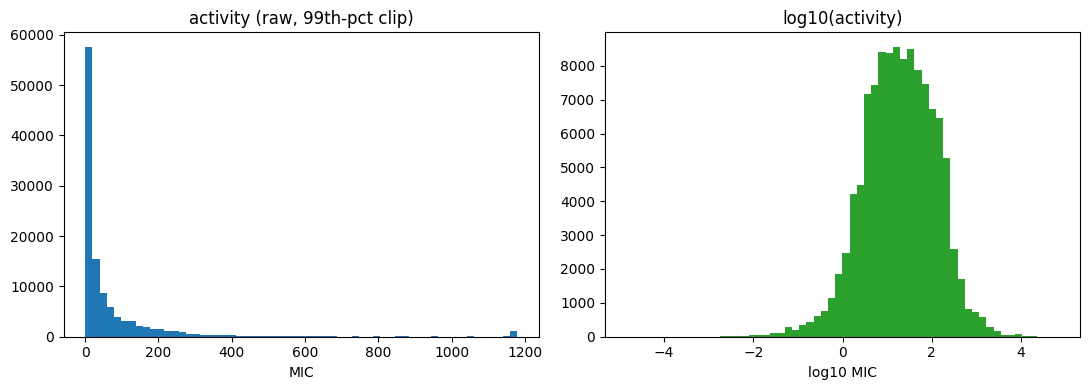

In [12]:
import matplotlib.pyplot as plt, numpy as np
a = raw['activity']
print("min:", a.min(), "| max:", a.max(), "| median:", a.median(), "| zeros:", int((a==0).sum()))
pos = a[a>0]
dynamic_range = np.log10(pos.max()) - np.log10(pos.min())
print(f"nonzero dynamic range: {dynamic_range:.1f} orders of magnitude")
fig, ax = plt.subplots(1, 2, figsize=(11,4))
ax[0].hist(a.clip(upper=a.quantile(0.99)), bins=60); ax[0].set_title('activity (raw, 99th-pct clip)'); ax[0].set_xlabel('MIC')
ax[1].hist(np.log10(pos), bins=60, color='C2'); ax[1].set_title('log10(activity)'); ax[1].set_xlabel('log10 MIC')
plt.tight_layout(); plt.show()

**Reading it:** raw MIC spans ~10 orders of magnitude and is extremely right-skewed;
in log space it is roughly bell-shaped. → **We regress on log₁₀ MIC**, and drop the
handful of exact zeros (log-undefined). A squared-error loss in log space is also what
makes a ±2-fold assay error a constant ~0.3-unit residual regardless of the MIC level.

### EDA 2 · Replicate structure & label noise
**Question:** how repeatable is a single MIC measurement? **Decision:** whether to
aggregate replicates and how robust the loss must be.

In [13]:
d = raw[raw['activity']>0].copy(); d['log_mic'] = np.log10(d['activity'])
pair = d.groupby(['sequence','target_activity_name'])['log_mic']
rep = pair.agg(['count','std']).dropna()
rep3 = rep[rep['count']>=3]
print("median within-(peptide,strain) replicate SD (log10):", round(rep3['std'].median(),3),
      "  -> ~", round(10**rep3['std'].median(),1), "fold typical spread")
print("(peptide,strain) pairs with >=2 measurements:", int((rep['count']>=2).sum()))

median within-(peptide,strain) replicate SD (log10): 0.389   -> ~ 2.4 fold typical spread
(peptide,strain) pairs with >=2 measurements: 5585


**Reading it:** the same peptide vs the same strain, remeasured, varies by ~0.3–0.4
log units (≈2-fold) — the classic MIC dilution-assay noise floor. → **We aggregate
replicate measurements by geometric mean (mean in log space)** and use a **Huber-style /
NLL loss** that does not let a few grossly-off replicates dominate. It also sets a
realistic error floor: don't expect test RMSE far below ~0.4.

### EDA 3 · The sequence alphabet (why not plain ESM-2)
**Question:** are these standard protein sequences? **Decision:** how to featurize, and
what ESM-2 can and cannot see.

In [14]:
from collections import Counter
allchars = Counter("".join(raw['sequence']))
std = set("ACDEFGHIKLMNPQRSTVWY")
nonstd = {c:n for c,n in allchars.items() if c not in std}
print("distinct characters:", len(allchars))
print("non-standard tokens (lowercase = D-amino acids; X, O, digits = modifications):")
print(dict(sorted(nonstd.items(), key=lambda kv:-kv[1])))
import amp_common as C
cls = raw['sequence'].drop_duplicates().map(C.classify_sequence).value_counts()
print("\nunique-sequence composition:"); print(cls)
print(f"standard-20 only: {cls.get('standard20_only',0)/cls.sum()*100:.1f}%")

distinct characters: 47
non-standard tokens (lowercase = D-amino acids; X, O, digits = modifications):
{'X': 41036, 'k': 14462, 'l': 12020, 'r': 10258, 'x': 6943, 'f': 5920, 'a': 5211, 'w': 5065, 'v': 4096, 'i': 3304, 's': 2967, 'p': 2542, 'y': 2421, 't': 2250, 'h': 1055, 'n': 849, 'q': 811, 'c': 619, 'd': 423, 'm': 327, 'e': 289, 'g': 131, 'O': 20, '2': 12, '(': 6, ')': 6, '3': 6}

unique-sequence composition:
sequence
standard20_only    12614
has_X_or_mod        2372
has_D_aa            1402
Name: count, dtype: int64
standard-20 only: 77.0%


**Reading it:** ~23% of unique peptides contain **D-amino acids** (lowercase),
`X`, or chemical modifications. ESM-2's vocabulary is the 20 standard **L**-amino acids
only — it has no D tokens and no notion of chirality. → In these notebooks the peptide
tower **uppercases** (so ESM-2 sees a valid L-peptide); the chirality-aware descriptor
features live in `amp_common` for the alternative models. If the D-signal is critical,
add those descriptors as extra peptide-tower inputs (see README).

### EDA 4 · Sequence length
**Question:** how long are the peptides? **Decision:** the ESM-2 `max_len` cap and the
VRAM budget (attention memory scales with length²).

{'min': 1.0, '25%': 12.0, '50%': 16.0, '75%': 23.0, 'max': 190.0}


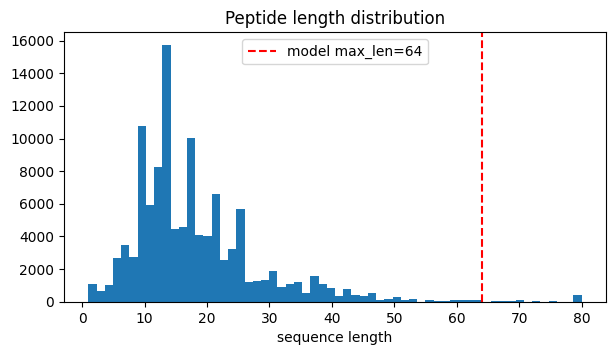

In [15]:
L = raw['sequence'].str.len()
print(L.describe()[['min','25%','50%','75%','max']].round(1).to_dict())
fig, ax = plt.subplots(figsize=(7,3.5)); ax.hist(L.clip(upper=80), bins=60)
ax.axvline(64, color='r', ls='--', label='model max_len=64'); ax.legend()
ax.set_xlabel('sequence length'); ax.set_title('Peptide length distribution'); plt.show()

**Reading it:** peptides are short (median ~16, most < 40). → `max_len=64` covers
the vast majority; the few longer ones are truncated. Short sequences also mean ESM-2's
length² attention cost is small, so a **free T4 GPU is sufficient**.

### EDA 5 · Organisms and the labeler choice
**Question:** the `target_activity_name` column has thousands of strain-level strings —
how do we turn them into modelable classes? **Decision:** the species labeler.

In [16]:
print("distinct raw target strings:", raw['target_activity_name'].nunique())
# Judge coverage on the AGGREGATED table (what the model trains on), not the raw rows:
agg_eda = C.keep_common_species(C.load_and_aggregate(DATA_PATH))   # geometric-mean aggregation + genus-species labeler + 700-row threshold
vc = agg_eda['species_m'].value_counts()
named = [s for s in vc.index if s != 'other']
print("named species (aggregated, >=700 rows):", len(named))
print("'other' share of aggregated rows: %.1f%%" % (vc['other']/len(agg_eda)*100))
print("\nNamed classes by row count:"); print(vc.to_string())

distinct raw target strings: 5811
named species (aggregated, >=700 rows): 15
'other' share of aggregated rows: 21.9%

Named classes by row count:
species_m
other                         23198
Staphylococcus aureus         19009
Escherichia coli              18077
Pseudomonas aeruginosa        12406
Klebsiella pneumoniae          4811
Candida albicans               4364
Acinetobacter baumannii        4358
Bacillus subtilis              4205
Salmonella enterica            3272
Staphylococcus epidermidis     3239
Enterococcus faecalis          2948
Micrococcus luteus             1428
Enterococcus faecium           1385
Salmonella typhimurium         1204
Bacillus cereus                1019
Listeria monocytogenes          899


**Reading it & the decision:** the raw column is strain-level
(`Escherichia coli ATCC 25922`, `... DH5alpha`, ...). We use a **general genus-species
labeler** = the first two tokens of the name, *not* a hardcoded keyword list. Why this
matters: species like **Staphylococcus epidermidis** are larger than ones a hardcoded
list already broke out (E. faecalis) — a fixed list wastes them in "other". On the
**production path** (the aggregated table the model actually trains on, threshold 700),
the general labeler lifts **13 → 15 named species** and drops "other" from
**24.5% → 21.9%** of aggregated rows, rescuing *S. epidermidis, E. faecium, B. cereus,
L. monocytogenes*. (More species clear 700 on the raw un-aggregated table — e.g.
E. cloacae at 705 — but after replicate aggregation they can fall just below and stay in
"other", so we always judge coverage on the aggregated table.) Rare/oddly-named targets
(e.g. "MRSA") fall into "other" at the threshold, so junk never contaminates a named
class. `keep_common_species(min_rows=700)` applies the threshold.

### EDA 6 · Why a similarity-clustered split (not a random split)
**Question:** can we trust a random train/test split? **Decision:** the evaluation protocol.

In [17]:
s2c = C.cluster_sequences(raw['sequence'].drop_duplicates().tolist())
import pandas as pd
nseq = raw['sequence'].nunique(); nclu = len(set(s2c.values()))
print(f"{nseq} unique peptides -> {nclu} similarity clusters (k-mer Jaccard >= 0.6)")
print(f"peptides sharing a near-duplicate: {nseq-nclu} "
      f"({(nseq-nclu)/nseq*100:.0f}% are in a multi-member cluster)")

16388 unique peptides -> 8319 similarity clusters (k-mer Jaccard >= 0.6)
peptides sharing a near-duplicate: 8069 (49% are in a multi-member cluster)


**Reading it:** roughly half the peptides have a near-duplicate elsewhere in the
data (single substitutions, length variants). A random row split would put near-twins in
both train and test, **inflating the score** by rewarding memorisation. → The training
engine splits by **similarity cluster**, so no peptide in test has a near-twin in train.
This is the honest estimate of novel-scaffold generalization and the number you should
trust.

# Model training
We now aggregate labels, build organism features, split by cluster, and train the
two-tower model with the **quantile** head. All of this is in `amp_towers.train_engine.train`;
the cell below just configures and calls it.

### Configure and train
**Reasoning for the defaults:** `esm2_t30_150M` frozen is the T4-friendly sweet spot —
frozen embeddings resist overfitting on ~16k peptides while two small trainable towers
sit on top. Training **early-stops on validation Spearman** because AMP screening is a
*ranking* task (which peptides to synthesise next), and Spearman measures ranking
directly and is robust to the label noise EDA-2 revealed.

In [18]:
#@title Train  { run: "auto" }
from amp_towers.model import TwoTowerConfig
from amp_towers.train_engine import train
import json

# --- pick the ESM-2 weights from HuggingFace -------------------------------
# facebook/*  : original ESM-2 weights, plain AutoModel (free T4, no extra deps).
# nvidia/*    : NVIDIA TransformerEngine-optimized ESM-2 (same weights); needs
#               trust_remote_code (auto) + `pip install transformer_engine` on an
#               NVIDIA GPU. Faster on A100/H100.
ESM_MODEL = "facebook/esm2_t33_650M_UR50D" #@param ["facebook/esm2_t12_35M_UR50D","facebook/esm2_t30_150M_UR50D","facebook/esm2_t33_650M_UR50D","nvidia/esm2_t33_650M_UR50D","nvidia/esm2_t36_3B_UR50D"]
FREEZE_ESM = True  #@param {type:"boolean"}
CACHE_EMBEDDINGS = True #@param {type:"boolean"}
EPOCHS    = 25    #@param {type:"integer"}
BATCH     = 64    #@param {type:"integer"}
LR        = 3e-4  #@param {type:"number"}

# esm_dim is AUTO-DETECTED from the model (320/480/640/1280/2560) — never set by hand.
#
# CACHE_EMBEDDINGS (only active when FREEZE_ESM): precompute each unique sequence's
# frozen ESM-2 embedding ONCE, then reuse it every epoch. Since a frozen LM's output
# never changes, this is exact (not an approximation) and is the dominant speedup for
# the 650M model: ~0.8 GB CPU RAM for this dataset, and it turns a ~7 min/epoch 650M
# run into ~30-60 s/epoch after a one-time ~3-5 min cache build. Turn OFF only if you
# unfreeze ESM-2 (fine-tuning must recompute) or are RAM-constrained.
if ESM_MODEL.startswith("nvidia/"):
    !pip -q install transformer_engine 2>/dev/null

cfg = TwoTowerConfig(esm_model_name=ESM_MODEL, freeze_esm=FREEZE_ESM,
                     cache_embeddings=CACHE_EMBEDDINGS, head_type="quantile", quantiles=(0.05, 0.5, 0.95))
model, history, test_metrics, aux = train(
    cfg, DATA_PATH, epochs=EPOCHS, lr=LR, batch_size=BATCH,
    out_prefix="twotower_quantile")
print("\nHELD-OUT TEST METRICS:\n", json.dumps(test_metrics, indent=2))

config.json:   0%|          | 0.00/724 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.61GB            

...

Loading weights:   0%|          | 0/534 [00:00<?, ?it/s]

[transformers] EsmModel LOAD REPORT from: facebook/esm2_t33_650M_UR50D
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[cache] 32/16386 sequences embedded
[cache] 672/16386 sequences embedded
[cache] 1312/16386 sequences embedded
[cache] 1952/16386 sequences embedded
[cache] 2592/16386 sequences embedded
[cache] 3232/16386 sequences embedded
[cache] 3872/16386 sequences embedded
[cache] 4512/16386 sequences embedded
[cache] 5152/16386 sequences embedded
[cache] 5792/16386 sequences embedded
[cache] 6432/16386 sequences embedded
[cache] 7072/16386 sequences embedded
[cache] 7712/16386 sequences embedded
[cache] 8352/16386 sequences embedded
[cache] 8992/16386 sequences embedded
[cache] 9632/16386 sequences embedded
[cache] 10272/16386 sequences embedded
[cache] 10912/16386 sequences embedded
[cache] 11552/16386 sequences embedded
[cache] 12192/16386 sequences embedded
[cache] 12832/16386 sequences embedded
[cache] 13472/16386 sequences embedded
[cache] 14112/16386 sequences embedded
[cache] 14752/16386 sequences embedded
[cache] 15392/16386 sequences embedded
[cache] 16032/16386 sequences embedded
[cach

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


{"epoch": 0, "train_loss": 0.1513, "val_time": 37.8, "val_RMSE": 0.7335, "val_MAE": 0.5657, "val_Pearson": 0.4595, "val_Spearman": 0.45, "val_within_2fold": 0.3482, "val_within_4fold": 0.6208, "val_PICP": 0.9349, "val_MPIW": 2.6218, "val_nominal": 0.9, "val_coverage_gap": 0.0349, "val_pinball": 0.1444}
{"epoch": 1, "train_loss": 0.1323, "val_time": 36.6, "val_RMSE": 0.6968, "val_MAE": 0.5433, "val_Pearson": 0.4805, "val_Spearman": 0.4703, "val_within_2fold": 0.3538, "val_within_4fold": 0.6339, "val_PICP": 0.8753, "val_MPIW": 2.0849, "val_nominal": 0.9, "val_coverage_gap": -0.0247, "val_pinball": 0.138}
{"epoch": 2, "train_loss": 0.1236, "val_time": 37.0, "val_RMSE": 0.6878, "val_MAE": 0.5309, "val_Pearson": 0.5057, "val_Spearman": 0.5009, "val_within_2fold": 0.3698, "val_within_4fold": 0.6503, "val_PICP": 0.8763, "val_MPIW": 2.0443, "val_nominal": 0.9, "val_coverage_gap": -0.0237, "val_pinball": 0.1356}
{"epoch": 3, "train_loss": 0.1175, "val_time": 37.4, "val_RMSE": 0.6978, "val_MAE":

### Training curves
**What to watch:** Spearman (the early-stop signal) should rise then plateau; for the
CI head, **PICP** (coverage) should approach the 0.90 nominal and **MPIW** (interval
width) should be as small as possible at that coverage.

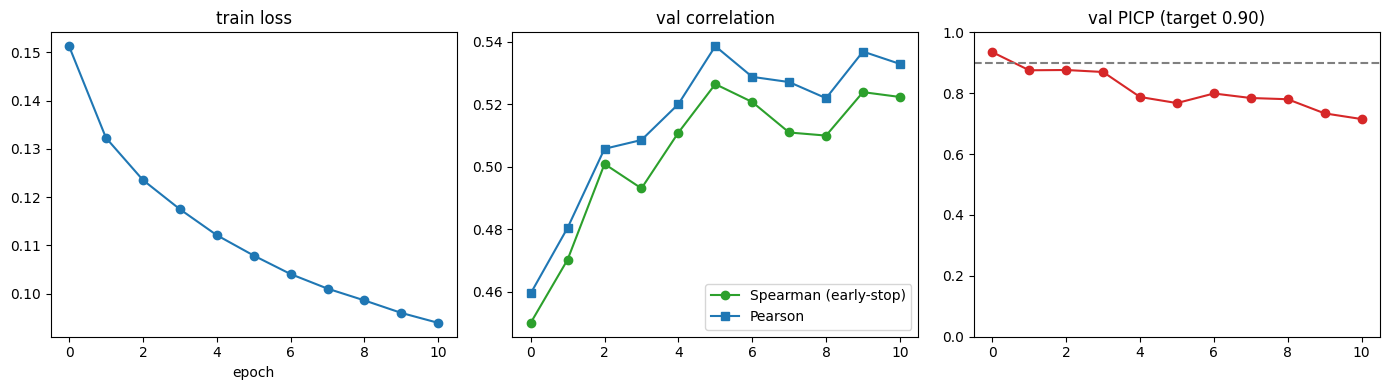

In [19]:
import pandas as pd, matplotlib.pyplot as plt
h = pd.DataFrame(history)
fig, ax = plt.subplots(1, 3, figsize=(14,4))
ax[0].plot(h['epoch'], h['train_loss'], 'o-'); ax[0].set_title('train loss'); ax[0].set_xlabel('epoch')
ax[1].plot(h['epoch'], h['val_Spearman'], 'o-', c='C2', label='Spearman (early-stop)')
ax[1].plot(h['epoch'], h['val_Pearson'], 's-', c='C0', label='Pearson'); ax[1].legend(); ax[1].set_title('val correlation')
if 'val_PICP' in h:
    ax[2].plot(h['epoch'], h['val_PICP'], 'o-', c='C3'); ax[2].axhline(0.90, ls='--', c='grey')
    ax[2].set_ylim(0,1); ax[2].set_title('val PICP (target 0.90)')
plt.tight_layout(); plt.show()

# Interpretation
**Why this section is not optional:** a single aggregate metric hides *where* the model
works. The tables and plots below answer: is it calibrated? which organisms/peptide
classes does it predict well? which residues and which organism features drive the
prediction? does the confidence interval actually cover what it claims?

### Per-group report — the key table
Spearman/RMSE broken out by **organism** and by **peptide class**
(standard-20 / D-amino-acid / X-modified). This is where you see, e.g., whether the
D-peptides are predicted as well as the standard ones.

In [20]:
import pandas as pd
rep = pd.read_csv(f"twotower_{cfg.head_type}_per_group_report.csv")
display(rep.round(3))

,grouping,group,n,RMSE,Pearson,Spearman,within_2fold
0,pep_class,standard20_only,14951,0.746,0.505,0.490,0.376
1,pep_class,has_X_or_mod,2892,0.785,0.398,0.375,0.369
2,pep_class,has_D_aa,1499,0.636,0.548,0.548,0.413
3,species_m,other,4282,0.859,0.442,0.402,0.322
4,species_m,Staphylococcus aureus,3496,0.702,0.536,0.495,0.384
5,species_m,Escherichia coli,3387,0.730,0.516,0.511,0.388
6,species_m,Pseudomonas aeruginosa,2209,0.609,0.493,0.494,0.440
7,species_m,Klebsiella pneumoniae,922,0.619,0.558,0.522,0.439
8,species_m,Acinetobacter baumannii,779,0.594,0.536,0.539,0.431
9,species_m,Candida albicans,779,0.734,0.342,0.282,0.329


### Predicted vs observed & calibration
**Why:** the scatter shows overall fit; the calibration curve shows whether predictions
are biased at the potent (low-MIC) or weak (high-MIC) ends — a model can have good
correlation yet be systematically shifted.

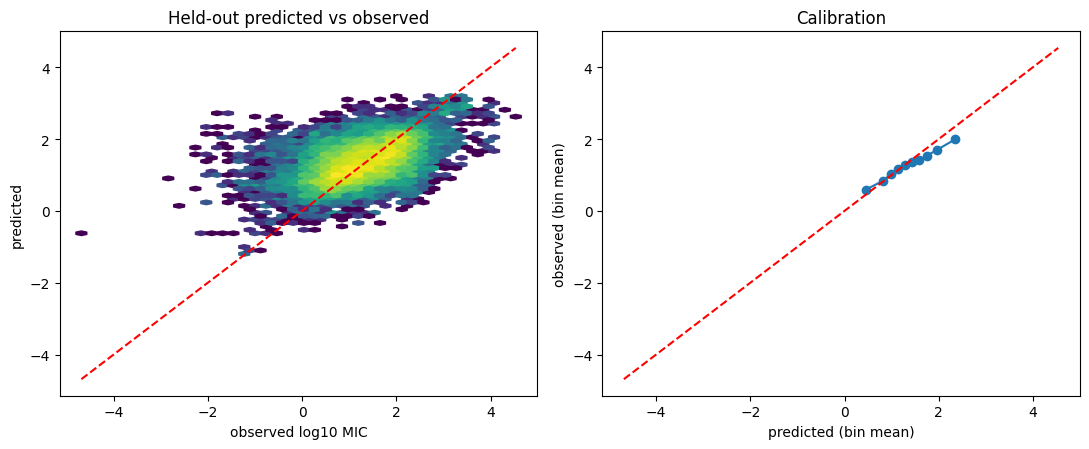

In [21]:
import numpy as np, matplotlib.pyplot as plt, torch
from amp_towers.train_engine import prepare_data, make_loaders, evaluate
from amp_towers import interpret as I
device = "cuda" if torch.cuda.is_available() else "cpu"
agg2 = prepare_data(DATA_PATH)
loaders, aux2 = make_loaders(agg2, cfg, batch_size=128)
_, y_test, pred_test = evaluate(model, loaders['test'], cfg, device)
fig, ax = plt.subplots(1,2, figsize=(11,4.6))
ax[0].hexbin(y_test, pred_test, gridsize=40, cmap='viridis', mincnt=1, bins='log')
lims=[min(y_test.min(),pred_test.min()), max(y_test.max(),pred_test.max())]
ax[0].plot(lims,lims,'r--'); ax[0].set_xlabel('observed log10 MIC'); ax[0].set_ylabel('predicted'); ax[0].set_title('Held-out predicted vs observed')
ct = I.calibration_table(y_test, pred_test, n_bins=10)
ax[1].plot(ct['pred_mean'], ct['obs_mean'], 'o-'); ax[1].plot(lims,lims,'r--')
ax[1].set_xlabel('predicted (bin mean)'); ax[1].set_ylabel('observed (bin mean)'); ax[1].set_title('Calibration')
plt.tight_layout(); plt.show()

### Interval reliability (does 90% mean 90%?)
**Why:** a confidence interval is only useful if it is *calibrated*. This reliability
diagram compares nominal vs empirical coverage; a gap means you should recalibrate
(σ temperature-scaling for the Gaussian head, or a conformal / non-crossing adjustment
for the quantile head).

In [22]:
import numpy as np, torch, pandas as pd
from amp_towers import interpret as I
qs = list(cfg.quantiles); preds=[]; ys=[]
model.eval()
with torch.no_grad():
    for seqs, sp, num, y in loaders['test']:
        out,_ = model(seqs, sp, num, device); preds.append(out.cpu().numpy()); ys.append(y.numpy())
qp = np.concatenate(preds); yv = np.concatenate(ys)
rd = I.reliability_diagram(yv, qp, qs)
print(rd.round(3).to_string(index=False))

 nominal  empirical    gap
    0.05      0.148  0.098
    0.50      0.525  0.025
    0.95      0.907 -0.043


### Peptide residue attention (motif discovery)
**Why:** the peptide tower's attention weights show which positions the model relies on —
often the cationic/hydrophobic residues that define an amphipathic AMP. A quick way to
sanity-check that the model learned biology, not artefacts.

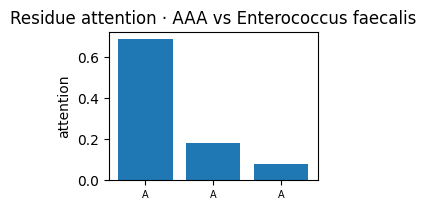

In [23]:
import numpy as np, matplotlib.pyplot as plt
from amp_towers import interpret as I
row = agg2[agg2.split=='test'].iloc[0]
sp_idx = aux2['sp2idx'][row['species_m']]
num_vec = aux2['org_feat'].loc[row['species_m'], aux2['num_cols']].values.astype('float32')
attn = I.peptide_residue_attention(model, row['sequence'], sp_idx, num_vec, device=device)
plt.figure(figsize=(min(14,0.3*len(row['sequence'])+2),2.2))
plt.bar(range(len(attn)), attn)
plt.xticks(range(len(attn)), list(row['sequence'][:len(attn)]), fontsize=7)
plt.title(f"Residue attention · {row['sequence'][:40]} vs {row['species_m']}"); plt.ylabel('attention')
plt.tight_layout(); plt.show()

# Save & download
`train()` wrote the weights, metrics, and per-group report. Download them for later
analysis or to resume training.

In [24]:
from google.colab import files
for f in ["twotower_quantile_model.pt","twotower_quantile_metrics.json","twotower_quantile_per_group_report.csv"]:
    try: files.download(f)
    except Exception as e: print("skip", f, e)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>